# 移除低质量的背鳍图片

In [1]:
import os
import glob
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt

In [4]:
# set root diretory and meta info file
root_dir = "/media/filming/2025-白海豚/20240825-JM_02-1/"
METAINFO_csv = root_dir + "/FIN_METAINFO.csv"
metainfo = pd.read_csv(METAINFO_csv, index_col=0)
# set threshold
clearness_threshold = 0.1
crop_conf_threshold = 0.4

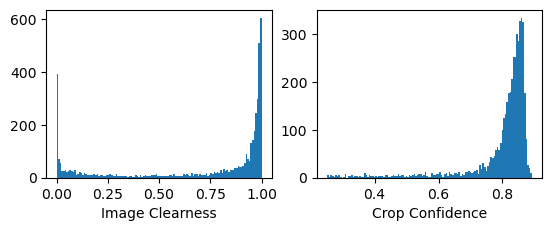

In [5]:
plt.subplot(221)
plt.hist(metainfo.clearness, bins=128)
plt.xlabel("Image Clearness")
plt.subplot(222)
plt.hist(metainfo.crop_conf, bins=128)
plt.xlabel("Crop Confidence")
plt.show()

In [6]:
# filter statistics
total_fin_num = len(metainfo)
selected_clearness_num = np.sum(metainfo.clearness > clearness_threshold)
selected_crop_conf_num = np.sum(metainfo.crop_conf > crop_conf_threshold)
metainfo["select"] = (metainfo.clearness > clearness_threshold ) * (metainfo.crop_conf > crop_conf_threshold)
clearness_annotation = "Clearness > %0.3f \n %d/%d"%(clearness_threshold, selected_clearness_num, total_fin_num)
crop_conf_annotation = "Crop confidence > %0.3f \n %d/%d"%(crop_conf_threshold, selected_crop_conf_num, total_fin_num)
final_selected_num = np.sum(metainfo.select)
final_selected_annotation = "Final selected: %d/%d"%(final_selected_num, total_fin_num)

In [7]:
metainfo.to_csv(root_dir + "FIN_METAINFO.csv")

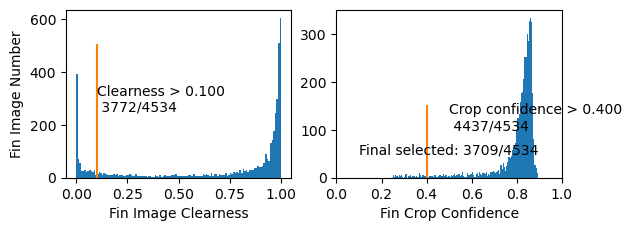

In [8]:
# plot statistics result
plt.subplot(221)
plt.hist(metainfo.clearness, bins=128)
plt.xlabel("Fin Image Clearness")
plt.ylabel("Fin Image Number")
plt.plot([clearness_threshold, clearness_threshold], [500, 0])
plt.annotate( clearness_annotation, [ clearness_threshold, 250])
plt.subplot(222)
plt.hist(metainfo.crop_conf, bins=128)
plt.xlabel("Fin Crop Confidence")
plt.xlim(0, 1)
plt.annotate( crop_conf_annotation, [ 0.5, 100])
plt.annotate( final_selected_annotation, [0.1, 50])
plt.plot([crop_conf_threshold, crop_conf_threshold], [150, 0])
plt.savefig(root_dir + "/fin_image_statistics.png")
plt.show()

In [9]:
# Soft link fin files
dest_dir = root_dir + "/FIN/BLUR/"
os.mkdir(dest_dir)
for fin in metainfo.query("clearness<%f"%clearness_threshold)['path']:
    src = root_dir + "/" + fin
    dest =  dest_dir + fin[4:]
    os.symlink(src, dest)

dest_dir = root_dir + "/FIN/LOW_CROP_CONFIDENCE/"
os.mkdir(dest_dir)
for fin in metainfo.query("crop_conf<%f"%crop_conf_threshold)['path']:
    src = root_dir + "/" + fin
    dest = dest_dir + fin[4:]
    os.symlink(src, dest)

dest_dir = root_dir + "/FIN/SELECTED/"
os.mkdir(dest_dir)
for fin in metainfo.query('select==True')['path']:
    src = root_dir + "/" + fin
    dest = dest_dir + fin[4:]
    os.symlink(src, dest)

# Here user confirm these fin image in folder
if it is placed in wrong folder, user move fin images to correct folders. Then this script should scan folder again to receive user confirmation.

In [10]:
# scan the fin structures from folder structure
scan_dir = root_dir + "/FIN/SELECTED/"
scan_list = os.listdir(scan_dir)
scan_list.sort()
scanned_img_list  = glob.glob(os.path.join(scan_dir, '*.JPG'))
scanned_img_list = [os.path.basename(path) for path in scanned_img_list]
# confirm the fin image move into SELETED folder
for img_name in scanned_img_list:
    if metainfo.loc[ metainfo['path'] == "FIN/"+ img_name, "select"].values[0] == False:
        print("User move", img_name, "into SELETED folder")
        metainfo.loc[ metainfo['path'] == "FIN/"+ img_name, "select"] = True
# confirm the fin image move out of SELECTED folder
for path in metainfo.loc[metainfo['select']==True, 'path']:
    img_name = os.path.basename(path)
    if img_name not in scanned_img_list:
        print("User move", img_name, "out SELETED folder")
        metainfo.loc[ metainfo['path'] == path, "select"] = False
# save to metainfo file
metainfo.to_csv(root_dir + "FIN_METAINFO.csv")

In [11]:
# move low quality orignal images to LOW QUALITY FOLDER
lowquality_img  = [i for i in metainfo.orig_img.unique() if i not in metainfo.loc[metainfo['select'] == True, 'orig_img'].unique()]
print("Total low quality images number:", len(lowquality_img))
for img in tqdm(lowquality_img):
    src = root_dir + "/" + img
    dest_dir = root_dir + "/Quality below 60"
    dest = dest_dir + "/" + img
    if not Path(dest_dir).exists():
        os.mkdir(dest_dir)
    if not os.path.exists(dest):
        os.symlink(src, dest)

Total low quality images number: 453


100%|██████████| 453/453 [00:00<00:00, 16320.81it/s]
